In [218]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay
)

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)
print("Libraries imported successfully.")

Libraries imported successfully.


**Task 1 Data Exploration**

In [219]:
df = pd.read_csv("US-pumpkins.csv")
print("First 5 records:")
display(df.head())

First 5 records:


,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,Mostly High,Origin,Origin District,Item Size,Color,Environment,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
0,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,4/29/17,270.0,280.0,270.0,280.0,MARYLAND,NaN,lge,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
1,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,5/6/17,270.0,280.0,270.0,280.0,MARYLAND,NaN,lge,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
2,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,160.0,DELAWARE,NaN,med,ORANGE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
3,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,160.0,VIRGINIA,NaN,med,ORANGE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
4,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,11/5/16,90.0,100.0,90.0,100.0,MARYLAND,NaN,lge,ORANGE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN


In [220]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1757
Number of columns: 26


In [221]:
print("column names:")
display(df.columns.tolist())

column names:


['City Name',
 'Type',
 'Package',
 'Variety',
 'Sub Variety',
 'Grade',
 'Date',
 'Low Price',
 'High Price',
 'Mostly Low',
 'Mostly High',
 'Origin',
 'Origin District',
 'Item Size',
 'Color',
 'Environment',
 'Unit of Sale',
 'Quality',
 'Condition',
 'Appearance',
 'Storage',
 'Crop',
 'Repack',
 'Trans Mode',
 'Unnamed: 24',
 'Unnamed: 25']

In [222]:
print("data types:\n")
print(df.dtypes)

data types:

City Name              str
Type                   str
Package                str
Variety                str
Sub Variety            str
Grade              float64
Date                   str
Low Price          float64
High Price         float64
Mostly Low         float64
Mostly High        float64
Origin                 str
Origin District        str
Item Size              str
Color                  str
Environment        float64
Unit of Sale           str
Quality            float64
Condition          float64
Appearance         float64
Storage            float64
Crop               float64
Repack                 str
Trans Mode         float64
Unnamed: 24        float64
Unnamed: 25            str
dtype: object


In [223]:
print("missing values:")
display(df.isnull().sum())

missing values:


City Name             0
Type               1712
Package               0
Variety               5
Sub Variety        1461
Grade              1757
Date                  0
Low Price             0
High Price            0
Mostly Low          103
Mostly High         103
Origin                3
Origin District    1626
Item Size           279
Color               616
Environment        1757
Unit of Sale       1595
Quality            1757
Condition          1757
Appearance         1757
Storage            1757
Crop               1757
Repack                0
Trans Mode         1757
Unnamed: 24        1757
Unnamed: 25        1654
dtype: int64

In [224]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1757 entries, 0 to 1756
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   City Name        1757 non-null   str    
 1   Type             45 non-null     str    
 2   Package          1757 non-null   str    
 3   Variety          1752 non-null   str    
 4   Sub Variety      296 non-null    str    
 5   Grade            0 non-null      float64
 6   Date             1757 non-null   str    
 7   Low Price        1757 non-null   float64
 8   High Price       1757 non-null   float64
 9   Mostly Low       1654 non-null   float64
 10  Mostly High      1654 non-null   float64
 11  Origin           1754 non-null   str    
 12  Origin District  131 non-null    str    
 13  Item Size        1478 non-null   str    
 14  Color            1141 non-null   str    
 15  Environment      0 non-null      float64
 16  Unit of Sale     162 non-null    str    
 17  Quality          0 non-nu

In [225]:
df.describe

<bound method NDFrame.describe of       City Name Type        Package      Variety Sub Variety  Grade     Date  \
0     BALTIMORE  NaN   24 inch bins          NaN         NaN    NaN  4/29/17   
1     BALTIMORE  NaN   24 inch bins          NaN         NaN    NaN   5/6/17   
2     BALTIMORE  NaN   24 inch bins  HOWDEN TYPE         NaN    NaN  9/24/16   
3     BALTIMORE  NaN   24 inch bins  HOWDEN TYPE         NaN    NaN  9/24/16   
4     BALTIMORE  NaN   24 inch bins  HOWDEN TYPE         NaN    NaN  11/5/16   
...         ...  ...            ...          ...         ...    ...      ...   
1752  ST. LOUIS  NaN  22 lb cartons    MINIATURE   FLAT TYPE    NaN  9/30/16   
1753  ST. LOUIS  NaN   36 inch bins    MINIATURE  ROUND TYPE    NaN  9/26/16   
1754  ST. LOUIS  NaN   36 inch bins    MINIATURE  ROUND TYPE    NaN  9/27/16   
1755  ST. LOUIS  NaN   36 inch bins    MINIATURE  ROUND TYPE    NaN  9/28/16   
1756  ST. LOUIS  NaN   36 inch bins    MINIATURE  ROUND TYPE    NaN  9/29/16   

     

In [226]:
print(df["Package"].value_counts(dropna=False))

Package
36 inch bins            663
24 inch bins            551
1/2 bushel cartons      234
1 1/9 bushel cartons    117
35 lb cartons            42
bushel cartons           37
40 lb cartons            19
1 1/9 bushel crates      17
each                     17
bins                     13
50 lb sacks              11
50 lb cartons            10
bushel baskets           10
22 lb cartons            10
20 lb cartons             6
Name: count, dtype: int64


In [227]:
# Keep records where Package contains "bushel"
bushel_df = df[
    df["Package"].astype(str).str.contains("bushel", case=False, na=False)
].copy()

print("Number of bushel records:", len(bushel_df))

display(bushel_df.head())


Number of bushel records: 415


,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,Mostly High,Origin,Origin District,Item Size,Color,Environment,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
70,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,9/24/16,15.0,15.0,15.0,15.0,DELAWARE,NaN,med,ORANGE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
71,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,9/24/16,18.0,18.0,18.0,18.0,DELAWARE,NaN,sml,ORANGE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
72,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,10/1/16,18.0,18.0,18.0,18.0,DELAWARE,NaN,sml,ORANGE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
73,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,10/1/16,17.0,17.0,17.0,17.0,OHIO,NaN,med,ORANGE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
74,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,10/8/16,15.0,15.0,15.0,15.0,DELAWARE,NaN,NaN,ORANGE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN


In [228]:
bushel_df = bushel_df[["Package", "Low Price", "High Price", "Date"]].copy()
display(bushel_df.head())

,Package,Low Price,High Price,Date
70,1 1/9 bushel cartons,15.0,15.0,9/24/16
71,1 1/9 bushel cartons,18.0,18.0,9/24/16
72,1 1/9 bushel cartons,18.0,18.0,10/1/16
73,1 1/9 bushel cartons,17.0,17.0,10/1/16
74,1 1/9 bushel cartons,15.0,15.0,10/8/16


In [229]:
bushel_df["Price"] = bushel_df["Low Price"] + bushel_df["High Price"] / 2
bushel_df.head()

,Package,Low Price,High Price,Date,Price
70,1 1/9 bushel cartons,15.0,15.0,9/24/16,22.5
71,1 1/9 bushel cartons,18.0,18.0,9/24/16,27.0
72,1 1/9 bushel cartons,18.0,18.0,10/1/16,27.0
73,1 1/9 bushel cartons,17.0,17.0,10/1/16,25.5
74,1 1/9 bushel cartons,15.0,15.0,10/8/16,22.5


In [230]:
bushel_df["Date"] = pd.to_datetime(bushel_df["Date"])
bushel_df["Month"] = bushel_df["Date"].dt.month
display(bushel_df.head())

,Package,Low Price,High Price,Date,Price,Month
70,1 1/9 bushel cartons,15.0,15.0,2016-09-24,22.5,9
71,1 1/9 bushel cartons,18.0,18.0,2016-09-24,27.0,9
72,1 1/9 bushel cartons,18.0,18.0,2016-10-01,27.0,10
73,1 1/9 bushel cartons,17.0,17.0,2016-10-01,25.5,10
74,1 1/9 bushel cartons,15.0,15.0,2016-10-08,22.5,10


In [231]:
pumpkins_df = bushel_df[["Month", "Package", "Low Price", "High Price", "Price"]].copy()
display(pumpkins_df.head())

,Month,Package,Low Price,High Price,Price
70,9,1 1/9 bushel cartons,15.0,15.0,22.5
71,9,1 1/9 bushel cartons,18.0,18.0,27.0
72,10,1 1/9 bushel cartons,18.0,18.0,27.0
73,10,1 1/9 bushel cartons,17.0,17.0,25.5
74,10,1 1/9 bushel cartons,15.0,15.0,22.5


In [232]:
# Filter records containing "bushel" in Package
bushel_df = df[
    df["Package"].astype(str).str.contains("bushel", case=False, na=False)
].copy()

# Select required columns
pumpkin_df = bushel_df[
    ["Package", "Low Price", "High Price", "Date"]
].copy()

# Convert Date to datetime
pumpkin_df["Date"] = pd.to_datetime(pumpkin_df["Date"])

# Extract month
pumpkin_df["Month"] = pumpkin_df["Date"].dt.month

# Calculate original average price
pumpkin_df["Price"] = (
    pumpkin_df["Low Price"] + pumpkin_df["High Price"]
) / 2

# Display result
display(pumpkin_df.head())


,Package,Low Price,High Price,Date,Month,Price
70,1 1/9 bushel cartons,15.0,15.0,2016-09-24,9,15.0
71,1 1/9 bushel cartons,18.0,18.0,2016-09-24,9,18.0
72,1 1/9 bushel cartons,18.0,18.0,2016-10-01,10,18.0
73,1 1/9 bushel cartons,17.0,17.0,2016-10-01,10,17.0
74,1 1/9 bushel cartons,15.0,15.0,2016-10-08,10,15.0


In [233]:
# Step 12: Adjust price for different package sizes

import re

def get_package_size(package):
    package = str(package).lower().strip()

    # Mixed fraction, e.g. "1 1/9 bushel"
    mixed_fraction = re.search(r'(\d+)\s+(\d+)\s*/\s*(\d+)', package)

    if mixed_fraction:
        whole = float(mixed_fraction.group(1))
        numerator = float(mixed_fraction.group(2))
        denominator = float(mixed_fraction.group(3))

        return whole + (numerator / denominator)

    # Simple fraction, e.g. "1/2 bushel"
    fraction = re.search(r'(\d+)\s*/\s*(\d+)', package)

    if fraction:
        numerator = float(fraction.group(1))
        denominator = float(fraction.group(2))

        return numerator / denominator

    # Whole number, e.g. "1 bushel"
    whole_number = re.search(r'(\d+(?:\.\d+)?)\s*bushel', package)

    if whole_number:
        return float(whole_number.group(1))

    return np.nan


# Extract package size
pumpkin_df["Package Size"] = pumpkin_df["Package"].apply(get_package_size)

# Display package and extracted size
display(
    pumpkin_df[["Package", "Package Size"]].drop_duplicates()
)

,Package,Package Size
70,1 1/9 bushel cartons,1.111111
123,1/2 bushel cartons,0.500000
377,1 1/9 bushel crates,1.111111
489,bushel cartons,NaN
1569,bushel baskets,NaN


In [234]:
# Calculate price per bushel

pumpkin_df["Low Price"] = (
    pumpkin_df["Low Price"] / pumpkin_df["Package Size"]
)

pumpkin_df["High Price"] = (
    pumpkin_df["High Price"] / pumpkin_df["Package Size"]
)

pumpkin_df["Price"] = (
    pumpkin_df["Low Price"] + pumpkin_df["High Price"]
) / 2

display(pumpkin_df.head())


,Package,Low Price,High Price,Date,Month,Price,Package Size
70,1 1/9 bushel cartons,13.5,13.5,2016-09-24,9,13.5,1.111111
71,1 1/9 bushel cartons,16.2,16.2,2016-09-24,9,16.2,1.111111
72,1 1/9 bushel cartons,16.2,16.2,2016-10-01,10,16.2,1.111111
73,1 1/9 bushel cartons,15.3,15.3,2016-10-01,10,15.3,1.111111
74,1 1/9 bushel cartons,13.5,13.5,2016-10-08,10,13.5,1.111111


**Task 2 Data Preprocessing**

In [235]:
pumpkins_df = pumpkin_df.dropna(
    subset=["Month", "Package", "Low Price", "High Price", "Price"]
). copy()

print("Final number of records:", len(pumpkins_df))

Final number of records: 368


In [236]:
monthly_price = (
    pumpkin_df
    .groupby("Month")["Price"]
    .mean()
    .reset_index()
)

monthly_price.columns = ["Month", "Average Price"]

display(monthly_price)


,Month,Average Price
0,8,24.366667
1,9,28.415650
2,10,28.329520
3,11,25.107018
4,12,15.412500


In [237]:
month_names = {
    1: "January",
    2: "February",
    3: "March",
    4: "April",
    5: "May",
    6: "June",
    7: "July",
    8: "August",
    9: "September",
    10: "October",
    11: "November",
    12: "December"
}

monthly_price["Month Name"] = monthly_price["Month"].map(month_names)

print(monthly_price)


   Month  Average Price Month Name
0      8      24.366667     August
1      9      28.415650  September
2     10      28.329520    October
3     11      25.107018   November
4     12      15.412500   December


In [238]:
highest_month = monthly_price.loc[
    monthly_price["Average Price"].idxmax()
]

lowest_month = monthly_price.loc[
    monthly_price["Average Price"].idxmin()
]

print(
    "Highest average price:",
    highest_month["Month Name"],
    "=", 
    round(highest_month["Average Price"], 2)
)

print(
    "Lowest average price:",
    lowest_month["Month Name"],
    "=",
    round(lowest_month["Average Price"], 2)
)


Highest average price: September = 28.42
Lowest average price: December = 15.41


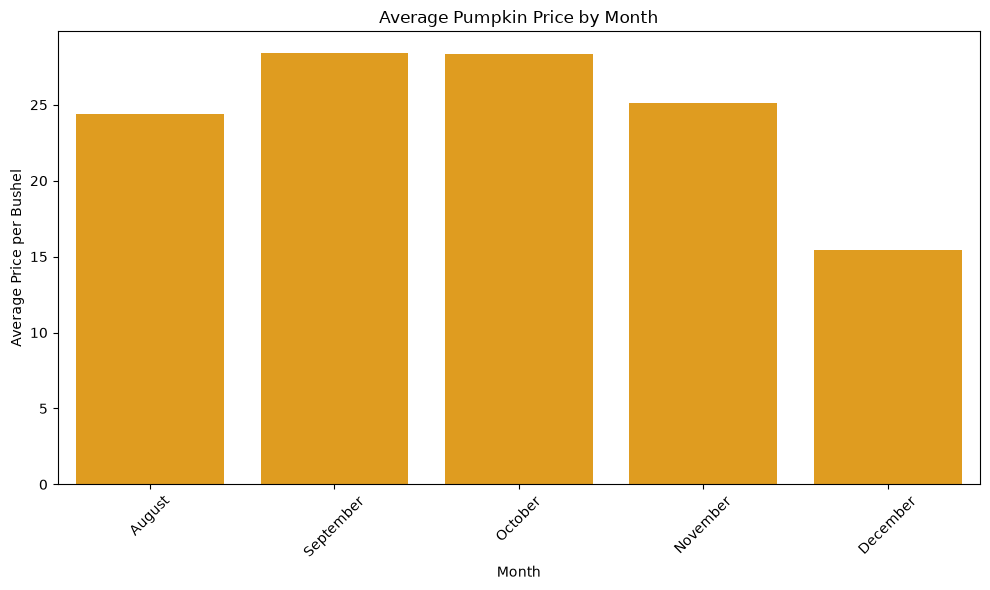

In [239]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=monthly_price,
    x="Month Name",
    y="Average Price",
    color="orange"
)

plt.title("Average Pumpkin Price by Month")
plt.xlabel("Month")
plt.ylabel("Average Price per Bushel")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


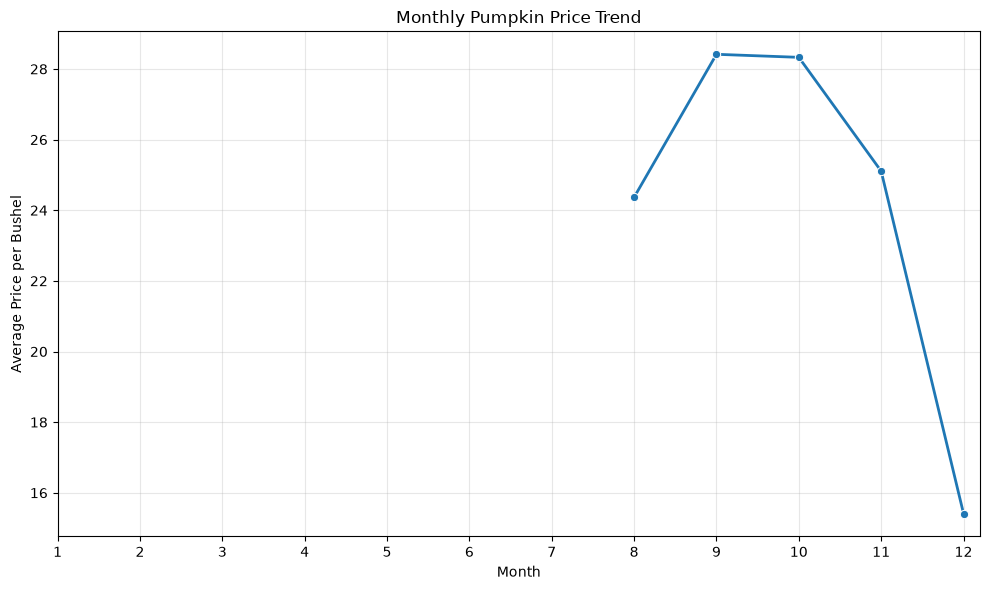

In [240]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=monthly_price,
    x="Month",
    y="Average Price",
    marker="o",
    linewidth=2
)

plt.title("Monthly Pumpkin Price Trend")
plt.xlabel("Month")
plt.ylabel("Average Price per Bushel")
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


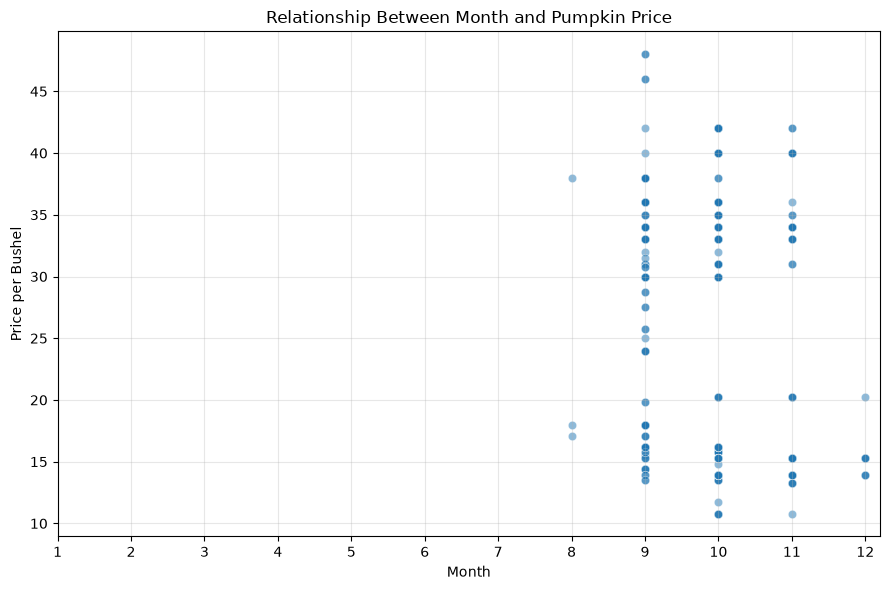

In [241]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=pumpkin_df,
    x="Month",
    y="Price",
    alpha=0.5
)

plt.title("Relationship Between Month and Pumpkin Price")
plt.xlabel("Month")
plt.ylabel("Price per Bushel")
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [242]:
correlation_df = pumpkin_df[
    ["Month", "Low Price", "High Price", "Price"]
]
correlation_matrix = correlation_df.corr()
display(correlation_matrix)


,Month,Low Price,High Price,Price
Month,1.000000,-0.149672,-0.154460,-0.153018
Low Price,-0.149672,1.000000,0.977520,0.993929
High Price,-0.154460,0.977520,1.000000,0.994783
Price,-0.153018,0.993929,0.994783,1.000000


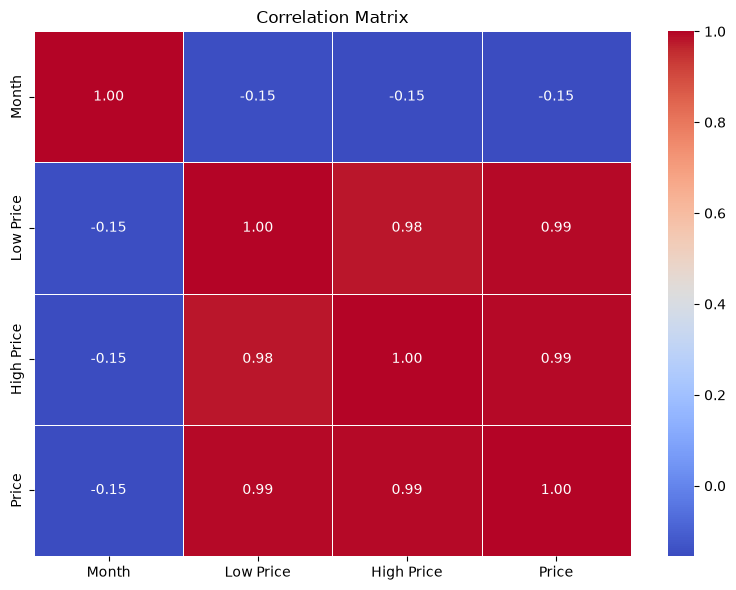

In [243]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


In [244]:
price_correlations = correlation_matrix["Price"].drop("Price")

strongest_variable = price_correlations.abs().idxmax()
strongest_correlation = price_correlations[strongest_variable]

print("Strongest relationship with Price:", strongest_variable)
print("Correlation:", round(strongest_correlation, 3))


Strongest relationship with Price: High Price
Correlation: 0.995


In [245]:
r = abs(strongest_correlation)

if r < 0.3:
    strength = "weak"
elif r < 0.7:
    strength = "moderate"
else:
    strength = "strong"

direction = "positive" if strongest_correlation > 0 else "negative"

print("Direction:", direction)
print("Strength:", strength)


Direction: positive
Strength: strong


In [246]:
# x = Month
# y = Price
X = pumpkin_df[["Month"]]
y = pumpkin_df[["Price"]]

print("X:")
display(X.head())

print("y:")
display(y.head())
                

X:


,Month
70,9
71,9
72,10
73,10
74,10


y:


,Price
70,13.5
71,16.2
72,16.2
73,15.3
74,13.5


In [247]:
# Part E - Simple Linear Regression

from sklearn.linear_model import LinearRegression

# Remove rows with missing Month or Price
model_df = pumpkin_df.dropna(
    subset=["Month", "Price"]
).copy()

# Prepare X and y
X = model_df[["Month"]]
y = model_df["Price"]

# Create the model
model = LinearRegression()

# Train the model
model.fit(X, y)

print("Model trained successfully!")
print("Number of records used:", len(model_df))


Model trained successfully!
Number of records used: 368


In [248]:
print("Missing values in X:")
print(X.isnull().sum())

print("\nMissing values in y:")
print(y.isnull().sum())


Missing values in X:
Month    0
dtype: int64

Missing values in y:
0


In [249]:
print(
    f"Price = {model.intercept_:.4f} "
    f"+ ({model.coef_[0]:.4f} × Month)"
)


Price = 46.7888 + (-1.9540 × Month)


In [250]:
# Part E - #25 Generate Predictions

# Generate predictions using the same X used to train the model
y_pred = model.predict(X)

# Add predictions to model_df
model_df["Predicted Price"] = y_pred

# Display actual vs predicted prices
comparison = model_df[
    ["Month", "Price", "Predicted Price"]
].copy()

display(comparison.head(10))


,Month,Price,Predicted Price
70,9,13.500,29.202716
71,9,16.200,29.202716
72,10,16.200,27.248711
73,10,15.300,27.248711
74,10,13.500,27.248711
75,10,16.200,27.248711
76,10,15.300,27.248711
77,10,15.975,27.248711
78,10,13.500,27.248711
79,10,15.300,27.248711


In [251]:
print("Number of rows:", len(model_df))
print("Number of predictions:", len(y_pred))


Number of rows: 368
Number of predictions: 368


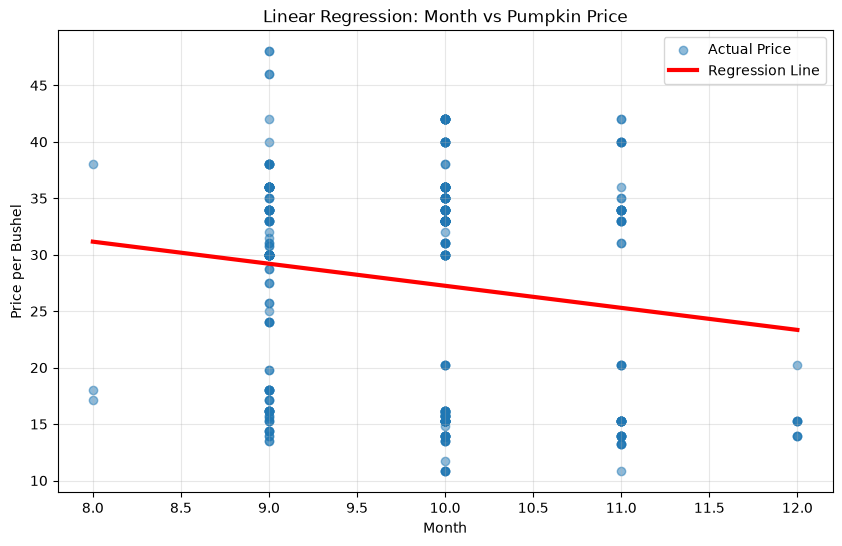

In [252]:
plt.figure(figsize=(10, 6))

# Actual prices
plt.scatter(
    model_df["Month"],
    model_df["Price"],
    alpha=0.5,
    label="Actual Price"
)

# Regression line
month_values = np.linspace(
    model_df["Month"].min(),
    model_df["Month"].max(),
    100
).reshape(-1, 1)

price_predictions = model.predict(month_values)

plt.plot(
    month_values,
    price_predictions,
    color="red",
    linewidth=3,
    label="Regression Line"
)

plt.title("Linear Regression: Month vs Pumpkin Price")
plt.xlabel("Month")
plt.ylabel("Price per Bushel")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [253]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(
    model_df["Price"],
    model_df["Predicted Price"]
)

mse = mean_squared_error(
    model_df["Price"],
    model_df["Predicted Price"]
)

r2 = r2_score(
    model_df["Price"],
    model_df["Predicted Price"]
)

print("MAE:", mae)
print("MSE:", mse)
print("R²:", r2)


MAE: 8.70045187048198
MSE: 93.24703498223224
R²: 0.023414365534992432


In [254]:
df = pd.read_csv("C:/Users/HomePC/Downloads/students_dataset.csv")
df.head()

,Feature_1,Feature_2,Feature_3,Feature_4,Target
0,61.22,29.73,86.57,3.17,Class_B
1,49.52,30.18,90.28,4.39,Class_A
2,65.90,39.07,70.51,2.28,Class_A
3,76.36,27.33,63.87,2.04,Class_B
4,55.15,25.03,78.91,2.82,Class_A


In [255]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Feature_1  600 non-null    float64
 1   Feature_2  600 non-null    float64
 2   Feature_3  600 non-null    float64
 3   Feature_4  600 non-null    float64
 4   Target     600 non-null    str    
dtypes: float64(4), str(1)
memory usage: 23.6 KB


In [256]:
df.describe()

,Feature_1,Feature_2,Feature_3,Feature_4
count,600.000000,600.000000,600.000000,600.000000
mean,64.489933,29.924467,101.094917,2.678467
std,12.154783,7.777202,32.018631,1.857127
min,28.080000,5.840000,36.030000,-2.570000
25%,56.392500,24.817500,74.617500,1.387500
50%,63.765000,29.975000,94.610000,2.665000
75%,73.305000,35.285000,125.687500,3.870000
max,101.480000,55.100000,186.520000,9.020000


In [257]:
df.shape

(600, 5)

In [258]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Check categorical and numerical columns
categorical_cols = df.select_dtypes(include=["object"]).columns
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns

print("Categorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numerical_cols)

Categorical columns:
Index(['Target'], dtype='str')

Numerical columns:
Index(['Feature_1', 'Feature_2', 'Feature_3', 'Feature_4'], dtype='str')


In [259]:
categorical_cols = df.select_dtypes(include=["object"]).columns
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns

print("Categorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numerical_cols)


Categorical columns:
Index(['Target'], dtype='str')

Numerical columns:
Index(['Feature_1', 'Feature_2', 'Feature_3', 'Feature_4'], dtype='str')


In [260]:
df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

print("Data after encoding:")
df_encoded.head()

Data after encoding:


,Feature_1,Feature_2,Feature_3,Feature_4,Target_Class_B
0,61.22,29.73,86.57,3.17,True
1,49.52,30.18,90.28,4.39,False
2,65.90,39.07,70.51,2.28,False
3,76.36,27.33,63.87,2.04,True
4,55.15,25.03,78.91,2.82,False


In [261]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_encoded)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=df_encoded.columns
)

print("Scaled data:")
X_scaled.head()

Scaled data:


,Feature_1,Feature_2,Feature_3,Feature_4,Target_Class_B
0,-0.269249,-0.025026,-0.454018,0.264895,1.006689
1,-1.232636,0.032884,-0.338051,0.922372,-0.993355
2,0.116106,1.176923,-0.956020,-0.214740,-0.993355
3,0.977391,-0.333877,-1.163572,-0.344079,1.006689
4,-0.769057,-0.629860,-0.693453,0.076274,-0.993355


In [262]:
print("Mean:")
print(X_scaled.mean().head())

print("\nStandard deviation:")
print(X_scaled.std().head())


Mean:
Feature_1         6.039613e-16
Feature_2        -9.547918e-17
Feature_3         1.302662e-16
Feature_4        -1.924387e-16
Target_Class_B    5.773160e-17
dtype: float64

Standard deviation:
Feature_1         1.000834
Feature_2         1.000834
Feature_3         1.000834
Feature_4         1.000834
Target_Class_B    1.000834
dtype: float64


In [263]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [264]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

print(inertia)

[2062.4002072317053, 1796.9327119075772, 1552.017493272327, 1384.6813418557324, 1244.5439090227535, 1153.4129829957026, 1054.5136849246992, 979.5930768083795, 918.2477491833299]


In [265]:
df.isnull().sum()

Feature_1    0
Feature_2    0
Feature_3    0
Feature_4    0
Target       0
dtype: int64

In [266]:
numerical_cols = df.select_dtypes(
    include=["int64", "float64"]
).columns

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

print(df.isnull().sum())

Feature_1    0
Feature_2    0
Feature_3    0
Feature_4    0
Target       0
dtype: int64


In [267]:
categorical_cols = df.select_dtypes(include=["object"]).columns

df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

print(df_encoded.isnull().sum().sum())

0


In [268]:
missing = df_encoded.isnull().sum()
print(missing[missing > 0])

Series([], dtype: int64)


In [269]:
df = df.dropna(axis=1, how="all")
df

,Feature_1,Feature_2,Feature_3,Feature_4,Target
0,61.22,29.73,86.57,3.17,Class_B
1,49.52,30.18,90.28,4.39,Class_A
2,65.90,39.07,70.51,2.28,Class_A
3,76.36,27.33,63.87,2.04,Class_B
4,55.15,25.03,78.91,2.82,Class_A
...,...,...,...,...,...
595,48.21,25.81,65.00,1.11,Class_A
596,49.66,27.38,76.49,2.17,Class_A
597,53.27,35.33,104.65,1.23,Class_B
598,88.12,23.46,74.74,3.80,Class_A


In [270]:
df = df.dropna(axis=1, how="all")

print("Shape:", df.shape)

Shape: (600, 5)


In [271]:
print(df.isnull().sum()[df.isnull().sum() > 0])

Series([], dtype: int64)


In [272]:
# Numerical columns
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

# Categorical columns
categorical_cols = df.select_dtypes(include=["object"]).columns

for col in categorical_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])

In [273]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


**Task 3 Feature Scaling**

In [274]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_encoded)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=df_encoded.columns
)

print("Missing values in scaled data:",
      X_scaled.isnull().sum().sum())

Missing values in scaled data: 0


In [275]:
categorical_cols = df.select_dtypes(include=["object"]).columns

df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

print("Missing values in df_encoded:",
      df_encoded.isnull().sum().sum())

Missing values in df_encoded: 0


In [276]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_encoded)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=df_encoded.columns
)

print("Missing values in scaled data:",
      X_scaled.isnull().sum().sum())

Missing values in scaled data: 0


In [277]:
print("df shape:", df.shape)
print("Encoded data shape:", df_encoded.shape)
print("Scaled data shape:", X_scaled.shape)

df shape: (600, 5)
Encoded data shape: (600, 5)
Scaled data shape: (600, 5)


**Task 4 Elbow Method**

In [278]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

print(inertia)

[2062.4002072317053, 1796.9327119075772, 1552.0174932723266, 1384.6813418557324, 1244.5439090227535, 1153.4129829957026, 1054.5136849246994, 979.5930768083795, 918.24774918333]


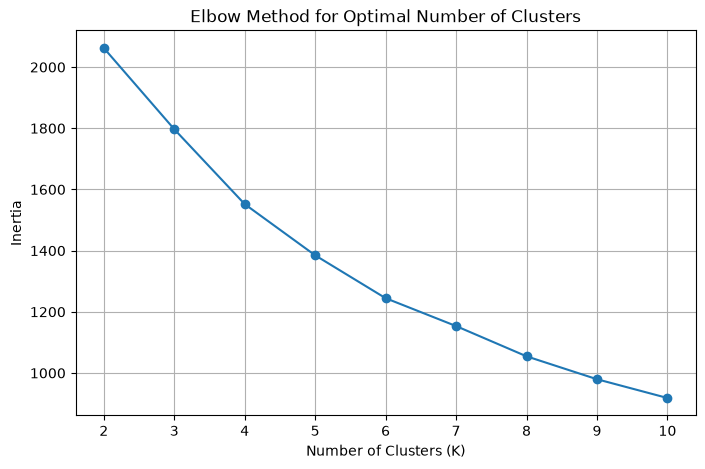

In [279]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    inertia,
    marker="o"
)

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(range(2, 11))
plt.grid(True)

plt.show()

**Task 5 Build the K-Means Model**

In [280]:
from sklearn.cluster import KMeans

optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_scaled)

df["Cluster"] = cluster_labels

print("Cluster column added successfully.")
print(df.head())

Cluster column added successfully.
   Feature_1  Feature_2  Feature_3  Feature_4   Target  Cluster
0      61.22      29.73      86.57       3.17  Class_B        1
1      49.52      30.18      90.28       4.39  Class_A        3
2      65.90      39.07      70.51       2.28  Class_A        0
3      76.36      27.33      63.87       2.04  Class_B        0
4      55.15      25.03      78.91       2.82  Class_A        3


In [281]:
print(df.columns.tolist())

['Feature_1', 'Feature_2', 'Feature_3', 'Feature_4', 'Target', 'Cluster']


In [282]:
print(df["Cluster"].value_counts().sort_index())

Cluster
0    130
1    146
2    149
3    175
Name: count, dtype: int64


In [283]:
print("df rows:", len(df))
print("X_scaled rows:", len(X_scaled))
print("Cluster labels:", len(cluster_labels))

df rows: 600
X_scaled rows: 600
Cluster labels: 600


In [284]:
numerical_cols = df.select_dtypes(
    include=["int64", "float64"]
).columns

print(numerical_cols)

Index(['Feature_1', 'Feature_2', 'Feature_3', 'Feature_4'], dtype='str')


**Task 6 Analyze the Data Segments**

In [285]:
numerical_cols = df.select_dtypes(
    include=["int64", "float64"]
).columns

numerical_cols = [
    col for col in numerical_cols
    if col != "Cluster"
]

print(numerical_cols)

['Feature_1', 'Feature_2', 'Feature_3', 'Feature_4']


In [286]:
cluster_summary = df.groupby("Cluster")[numerical_cols].mean()

print(cluster_summary.round(2))

         Feature_1  Feature_2  Feature_3  Feature_4
Cluster                                            
0            75.87      30.90      80.91       3.64
1            61.13      29.88     120.05       4.09
2            68.30      30.72     131.41       0.81
3            55.60      28.56      74.46       2.39


In [287]:
# Select numerical columns
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns

# Remove the Cluster column
numerical_cols = [
    col for col in numerical_cols
    if col != "Cluster"
]

# Calculate the average of numerical variables for each cluster
cluster_summary = df.groupby("Cluster")[numerical_cols].mean()

# Display the result
print(cluster_summary.round(2))

         Feature_1  Feature_2  Feature_3  Feature_4
Cluster                                            
0            75.87      30.90      80.91       3.64
1            61.13      29.88     120.05       4.09
2            68.30      30.72     131.41       0.81
3            55.60      28.56      74.46       2.39


In [288]:
cluster_counts = df["Cluster"].value_counts().sort_index()

print("Number of observations in each cluster:")
print(cluster_counts)

Number of observations in each cluster:
Cluster
0    130
1    146
2    149
3    175
Name: count, dtype: int64


In [289]:
categorical_cols = df.select_dtypes(include=["object"]).columns

print("Categorical columns:")
print(categorical_cols)

Categorical columns:
Index(['Target'], dtype='str')


In [290]:
for col in categorical_cols:
    print("\n" + "=" * 50)
    print("Column:", col)
    print("=" * 50)
    print(pd.crosstab(df["Cluster"], df[col]))


Column: Target
Target   Class_A  Class_B
Cluster                  
0            129        1
1              0      146
2              2      147
3            171        4


In [291]:
for col in categorical_cols:
    print("\n" + "=" * 50)
    print("Column:", col)
    print("=" * 50)
    
    percentage_table = pd.crosstab(
        df["Cluster"],
        df[col],
        normalize="index"
    ) * 100
    
    print(percentage_table.round(2))


Column: Target
Target   Class_A  Class_B
Cluster                  
0          99.23     0.77
1           0.00   100.00
2           1.34    98.66
3          97.71     2.29


**Task 7**

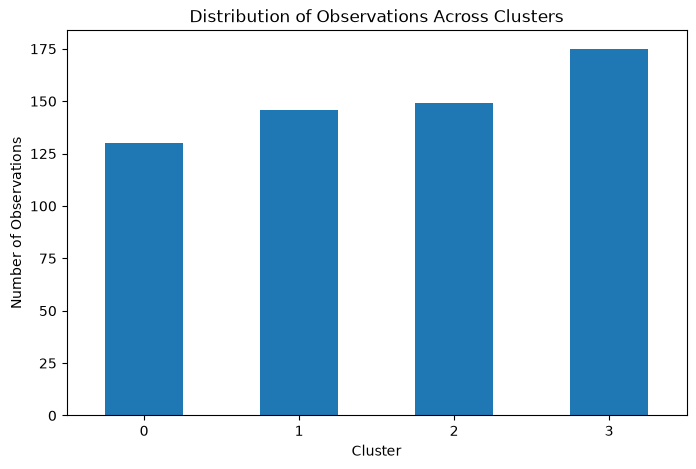

In [292]:
import matplotlib.pyplot as plt

cluster_counts = df["Cluster"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
cluster_counts.plot(kind="bar")

plt.title("Distribution of Observations Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Observations")
plt.xticks(rotation=0)

plt.show()

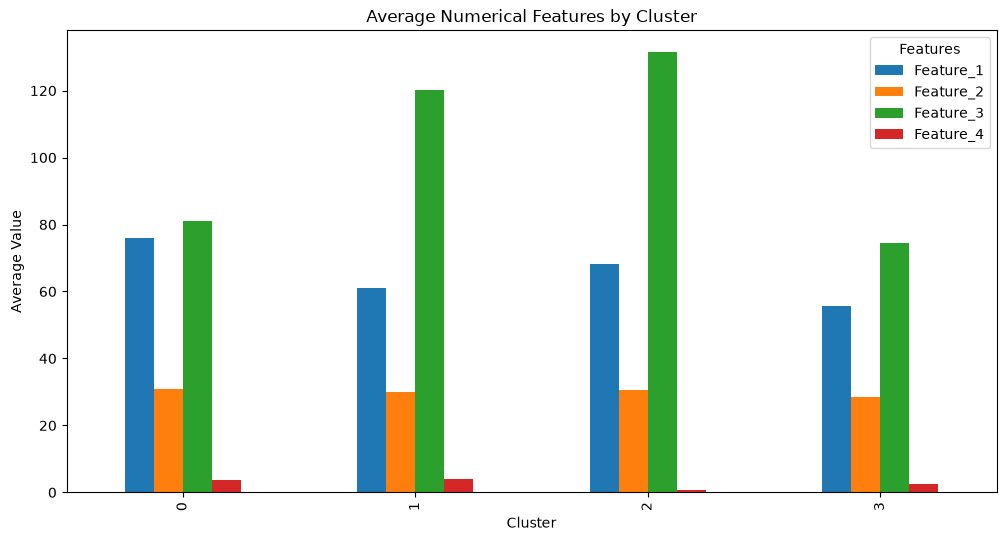

In [293]:
cluster_summary.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Average Numerical Features by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Value")
plt.legend(title="Features")

plt.show()

In [294]:
print(df.columns.tolist())

['Feature_1', 'Feature_2', 'Feature_3', 'Feature_4', 'Target', 'Cluster']


In [295]:
print(numerical_cols)

['Feature_1', 'Feature_2', 'Feature_3', 'Feature_4']


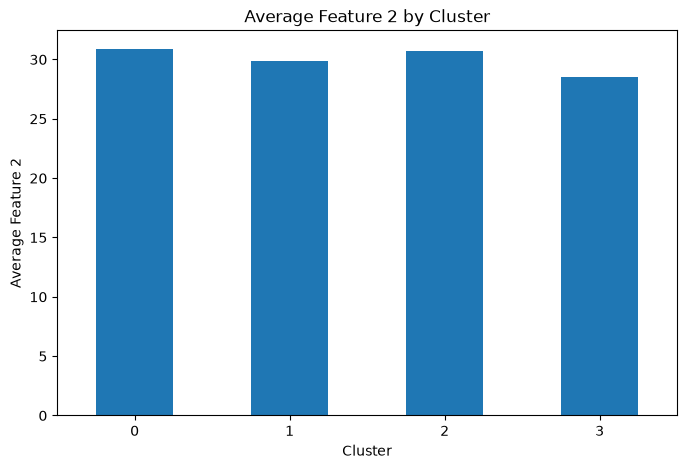

In [296]:
plt.figure(figsize=(8, 5))

df.groupby("Cluster")["Feature_2"].mean().plot(kind="bar")

plt.title("Average Feature 2 by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Feature 2")
plt.xticks(rotation=0)

plt.show()

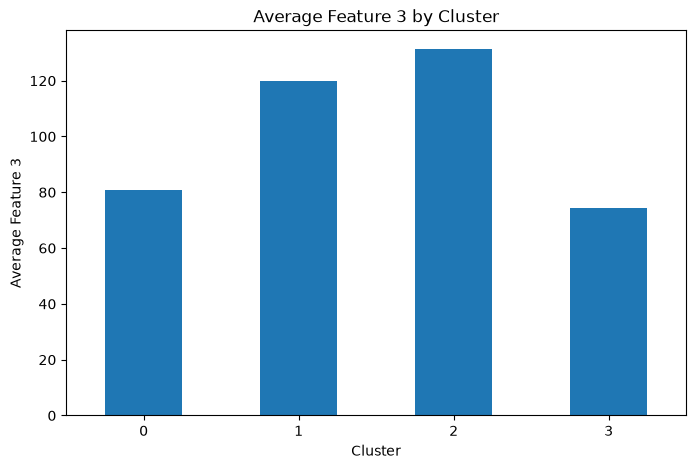

In [297]:
plt.figure(figsize=(8, 5))

df.groupby("Cluster")["Feature_3"].mean().plot(kind="bar")

plt.title("Average Feature 3 by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Feature 3")
plt.xticks(rotation=0)

plt.show()

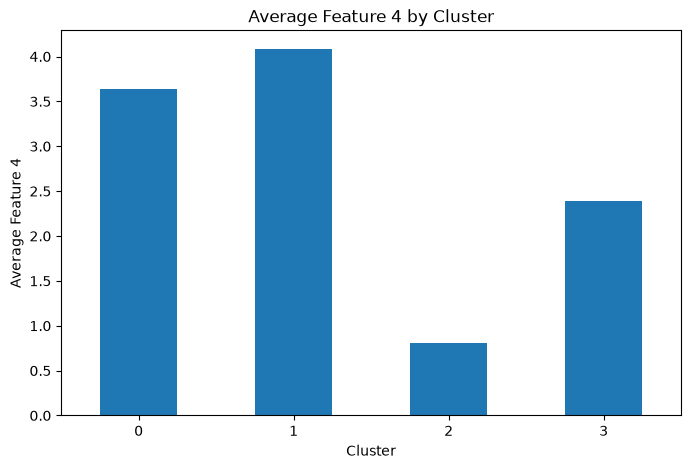

In [298]:
plt.figure(figsize=(8, 5))

df.groupby("Cluster")["Feature_4"].mean().plot(kind="bar")

plt.title("Average Feature 4 by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Feature 4")
plt.xticks(rotation=0)

plt.show()

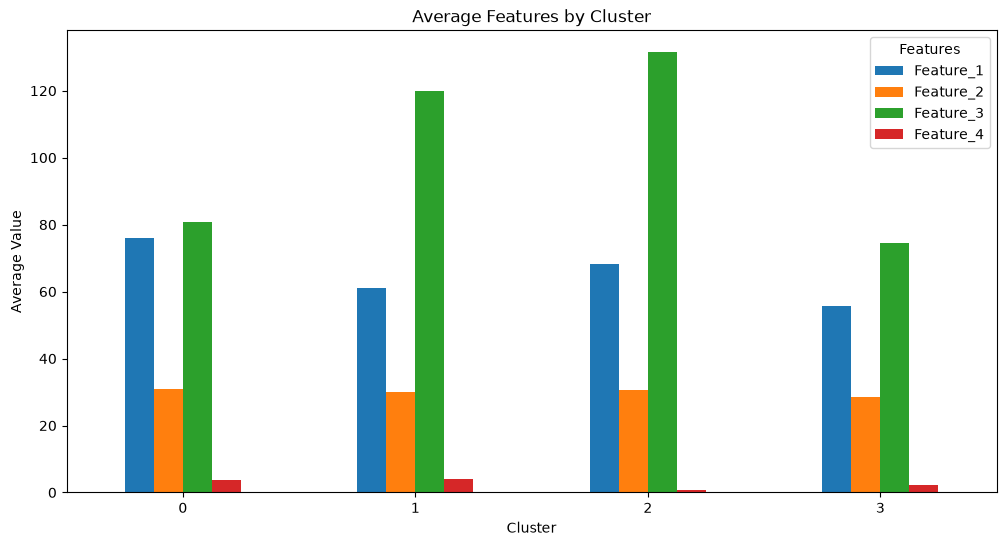

In [299]:
feature_summary = df.groupby("Cluster")[
    ["Feature_1", "Feature_2", "Feature_3", "Feature_4"]
].mean()

feature_summary.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Average Features by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.legend(title="Features")

plt.show()

**Task 8**


In [300]:
cluster_summary = df.groupby("Cluster")[
    ["Feature_1", "Feature_2", "Feature_3", "Feature_4"]
].mean()

print(cluster_summary.round(2))

         Feature_1  Feature_2  Feature_3  Feature_4
Cluster                                            
0            75.87      30.90      80.91       3.64
1            61.13      29.88     120.05       4.09
2            68.30      30.72     131.41       0.81
3            55.60      28.56      74.46       2.39


In [301]:
print("Cluster Characteristics:")
print(cluster_summary.round(2))

Cluster Characteristics:
         Feature_1  Feature_2  Feature_3  Feature_4
Cluster                                            
0            75.87      30.90      80.91       3.64
1            61.13      29.88     120.05       4.09
2            68.30      30.72     131.41       0.81
3            55.60      28.56      74.46       2.39


**Identifying the highest and lowest values**

In [302]:
for cluster in cluster_summary.index:
    print(f"\nCluster {cluster}")
    print("Highest:", cluster_summary.loc[cluster].idxmax(),
          "=", cluster_summary.loc[cluster].max())
    print("Lowest:", cluster_summary.loc[cluster].idxmin(),
          "=", cluster_summary.loc[cluster].min())


Cluster 0
Highest: Feature_3 = 80.91492307692307
Lowest: Feature_4 = 3.6363846153846153

Cluster 1
Highest: Feature_3 = 120.05047945205479
Lowest: Feature_4 = 4.085890410958904

Cluster 2
Highest: Feature_3 = 131.41389261744965
Lowest: Feature_4 = 0.8067114093959732

Cluster 3
Highest: Feature_3 = 74.45697142857142
Lowest: Feature_4 = 2.386342857142857


**Check cluster sizes**

In [303]:
print(df["Cluster"].value_counts().sort_index())

Cluster
0    130
1    146
2    149
3    175
Name: count, dtype: int64


**Task 9 Recommendations**

Step 9.1 Get the cluster averages

In [304]:
cluster_summary = df.groupby("Cluster")[
    ["Feature_1", "Feature_2", "Feature_3", "Feature_4"]
].mean()

print(cluster_summary.round(2))

         Feature_1  Feature_2  Feature_3  Feature_4
Cluster                                            
0            75.87      30.90      80.91       3.64
1            61.13      29.88     120.05       4.09
2            68.30      30.72     131.41       0.81
3            55.60      28.56      74.46       2.39


Step 9.2 Recommendations for the analysis

**Recommendations**

**Develop strategies for each cluster:** The observations should be treated as different groups because K-Means identified four distinct clusters. Decisions can be tailored according to the characteristics of each cluster.

**Focus on the largest cluster:** Cluster 3 contains 175 observations, representing the largest group. Its characteristics should be examined carefully to understand the common patterns within this segment.

**Investigate smaller clusters:** Cluster 0 contains 130 observations and should also be examined to understand why it differs from the larger groups.

**Use feature differences for decision-making:** The average values of Feature 1–Feature 4 should be compared across clusters to identify the variables responsible for the differences between the groups.

**Monitor the clusters over time:** New observations can be assigned to the existing clusters to determine whether the characteristics of the groups change over time.

**Use clustering to support better decisions:** The segmentation can help an organization understand patterns within its data and develop strategies that are appropriate for different groups instead of treating all observations in the same way.